In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anastruct as ast

np.set_printoptions(suppress=True, precision=3)

In [178]:
L_x = [6,7,7,6] # m
h_z = [4,3,3,3,3,3] # m
at = 6 # m

In [179]:
fc = 280 # kg/cm²
Ec = 15000 * fc**0.5 * 10 # ton/m²

c_b = 0.5
c_h = 0.5
v_b = 0.3
v_h = 0.6

A_c = c_b * c_h
I_c = c_b * c_h**3 / 12
A_v = v_b * v_h
I_v = v_b * v_h**3 / 12

In [180]:
ejes_x = [0]
for x in L_x: ejes_x.append(ejes_x[-1]+x)

ejes_z = [0]
for z in h_z: ejes_z.append(ejes_z[-1]+z)
print(ejes_x)
print(ejes_z)

[0, 6, 13, 20, 26]
[0, 4, 7, 10, 13, 16, 19]


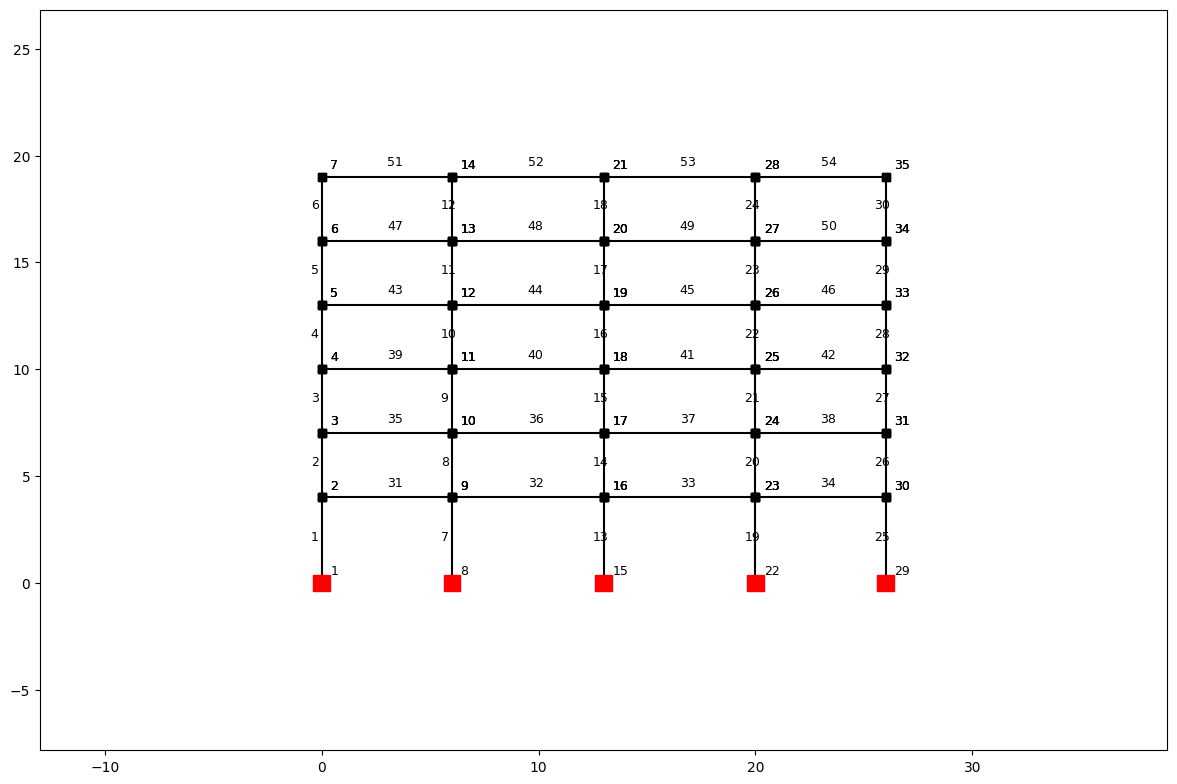

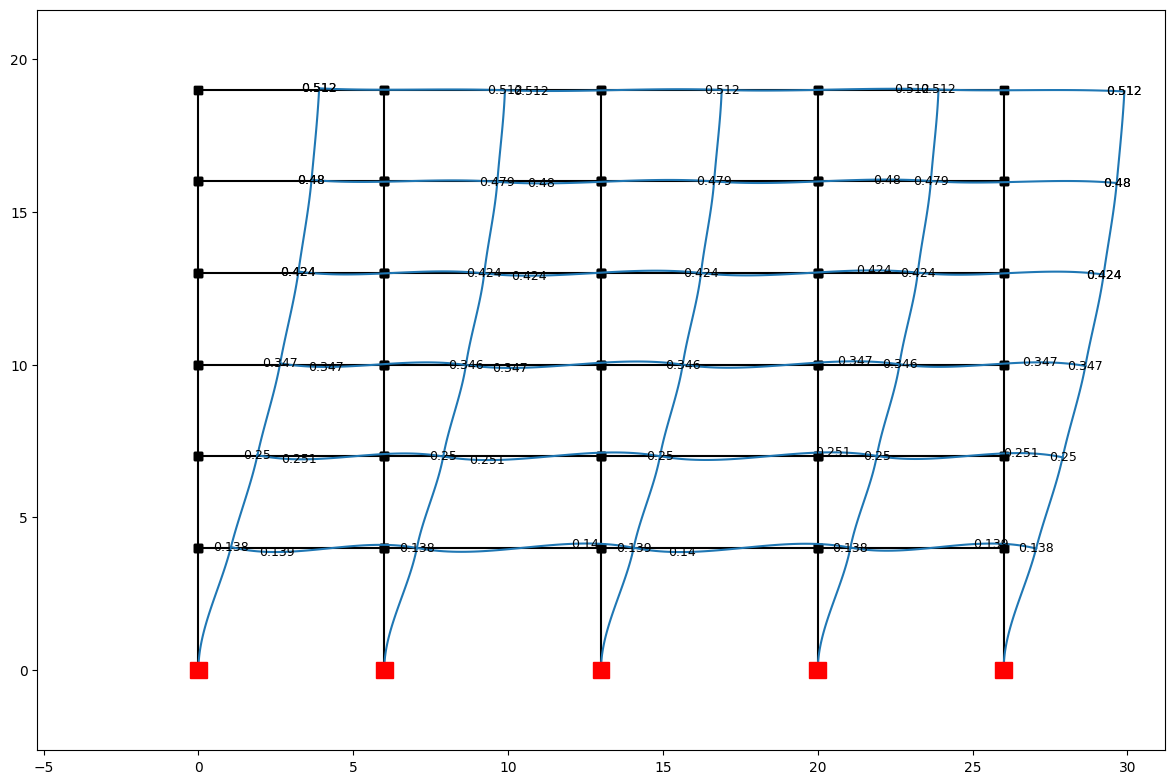

In [181]:
ss = ast.SystemElements()

# modelamiento de columnas
for i in range(len(ejes_x)):
    for j in range(len(h_z)):
        ss.add_element([[ejes_x[i],ejes_z[j]],[ejes_x[i],ejes_z[j+1]]], EA = Ec*A_c, EI = Ec*I_c)

# modelamiento de vigas
for i in range(len(h_z)):
    for j in range(len(L_x)):
        ss.add_element([[ejes_x[j],ejes_z[i+1]],[ejes_x[j+1],ejes_z[i+1]]], EA = Ec*A_v, EI = Ec*I_v)

# Asignación de apoyos empotrados

for i in range(len(ejes_x)):
    ss.add_support_fixed(node_id=len(ejes_z)*i+1)

# Asignación de cargas

# Load Case Dead
w1 = 2.4 * 0.2 * at # Peso propio de la losa, ton/m
w2 = 2.4 * A_v # Peso propio de la viga, ton/m
w3 = at * (0.100 + 0.250) # acabados + tabiquería, ton/m
lc_D = ast.LoadCase("Dead")
for viga in range(len(ejes_x)*len(h_z)+1,len(ejes_x)*len(h_z)+len(h_z)*len(L_x)+1):
    lc_D.q_load(q = -round(w1+w2+w3,2), element_id=viga, direction="y")
for col in range(1,len(ejes_x)*len(h_z)+1):
    lc_D.q_load(q = -A_c*2.4, element_id=col, direction="y")

# Load Case Live
l1 = 0.250 * at # Peso propio de la losa, ton/m
lc_L = ast.LoadCase("Live")
for viga in range(len(ejes_x)*len(h_z)+1,len(ejes_x)*len(h_z)+len(h_z)*len(L_x)+1):
    lc_L.q_load(q = -round(l1,2), element_id=viga)#, direction="y")



# Load Case EarthQuake
lc_E = ast.LoadCase("EarthQuake")
E = [100, 130, 150,180,200,230]
for i in range(len(h_z)):
    for j in range(len(ejes_x)):
        lc_E.point_load(Fx=round(E[i]/len(ejes_x),1), node_id=2+j*len(ejes_z)+i)

ss.show_structure()
ss.apply_load_case(lc_E)
ss.solve()
ss.show_displacement(scale=0.7)

In [182]:
CombMasa = ast.LoadCombination("Peso Sismico")
CombMasa.add_load_case(lc_D, 1.00)
CombMasa.add_load_case(lc_L, 0.25)

Comb1 = ast.LoadCombination("Combo 1")
Comb1.add_load_case(lc_D, 1.4)
Comb1.add_load_case(lc_L, 1.7)

Comb2 = ast.LoadCombination("Combo 2")
Comb2.add_load_case(lc_D, 1.25)
Comb2.add_load_case(lc_L, 1.25)
Comb2.add_load_case(lc_E, 1)

Comb3 = ast.LoadCombination("Combo 3")
Comb3.add_load_case(lc_D, 1.25)
Comb3.add_load_case(lc_L, 1.25)
Comb3.add_load_case(lc_E, -1)

Comb4 = ast.LoadCombination("Combo 4")
Comb4.add_load_case(lc_D, 0.90)
Comb4.add_load_case(lc_E, 1)

Comb5 = ast.LoadCombination("Combo 5")
Comb5.add_load_case(lc_D, 0.90)
Comb5.add_load_case(lc_E, -1)

In [ ]:
# Cálculo de masa por piso
r = CombMasa.solve(ss)
s_masa = r["combination"]
pesos = []
for i in range(1,len(h_z)+1):
    pesos.append(0)
    for j in range(len(ejes_x)):
        #print(i+j*len(h_z))
        res = s_masa.get_element_results(element_id=i+j*len(h_z), verbose=True)
        N = -res["N"][int(len(res["N"])/2)]
        pesos[-1] += N
        #print(N)
        #print(pesos)
print(pesos)
for i in range(len(h_z)-1):
    pesos[i] = pesos[i] - pesos[i+1]

print(pesos)

ss.remove_loads()

# Cálculo de rigidez
# Para este procedimiento se calculará una matriz de flexibilidad
u_matrix = []
for i in range(len(h_z)):
    ss.point_load(node_id=i+2, Fx=1000)
    #ss.show_structure(scale=0.7)
    ss.solve()
    #ss.show_displacement()
    u_matrix.append([])
    for k in range(2,len(h_z)+2):
        temp = ss.get_node_displacements(k)["ux"]
        print("Temp",k,temp)
        u_matrix[-1].append(temp)
    ss.remove_loads()
u_matrix = np.array(u_matrix).T
print(u_matrix)
k_matrix = np.linalg.inv(u_matrix)/1000
print(k_matrix)

rigideces = []
for i in range(len(h_z)):
    rigideces.append(k_matrix[len(h_z)-1-i,len(h_z)-1-i])

[np.float64(953.3375510204085), np.float64(792.4581632653067), np.float64(633.0481632653056), np.float64(473.63816326530707), np.float64(314.22816326530597), np.float64(154.8181632653047)]
[np.float64(160.8793877551018), np.float64(159.4100000000011), np.float64(159.4099999999985), np.float64(159.4100000000011), np.float64(159.41000000000128), np.float64(154.8181632653047)]
Temp 2 0.1263628592828315
Temp 3 0.14017604724964847
Temp 4 0.14207997332120337
Temp 5 0.14313588536947194
Temp 6 0.14341080484132912
Temp 7 0.14359452412204754
Temp 2 0.14017604724964847
Temp 3 0.2533604111297071
Temp 4 0.2676932217327535
Temp 5 0.27006559219363985
Temp 6 0.2714668325480288
Temp 7 0.27212260082425993
Temp 2 0.14207997332120323
Temp 3 0.2676932217327533
Temp 4 0.3807027512823024
Temp 5 0.39566055211185774
Temp 6 0.3985566987000094
Temp 7 0.40057079039891447
Temp 2 0.14313588536947175
Temp 3 0.2700655921936397
Temp 4 0.39566055211185763
Temp 5 0.5094856464792158
Temp 6 0.5251615366307798
Temp 7 0.529

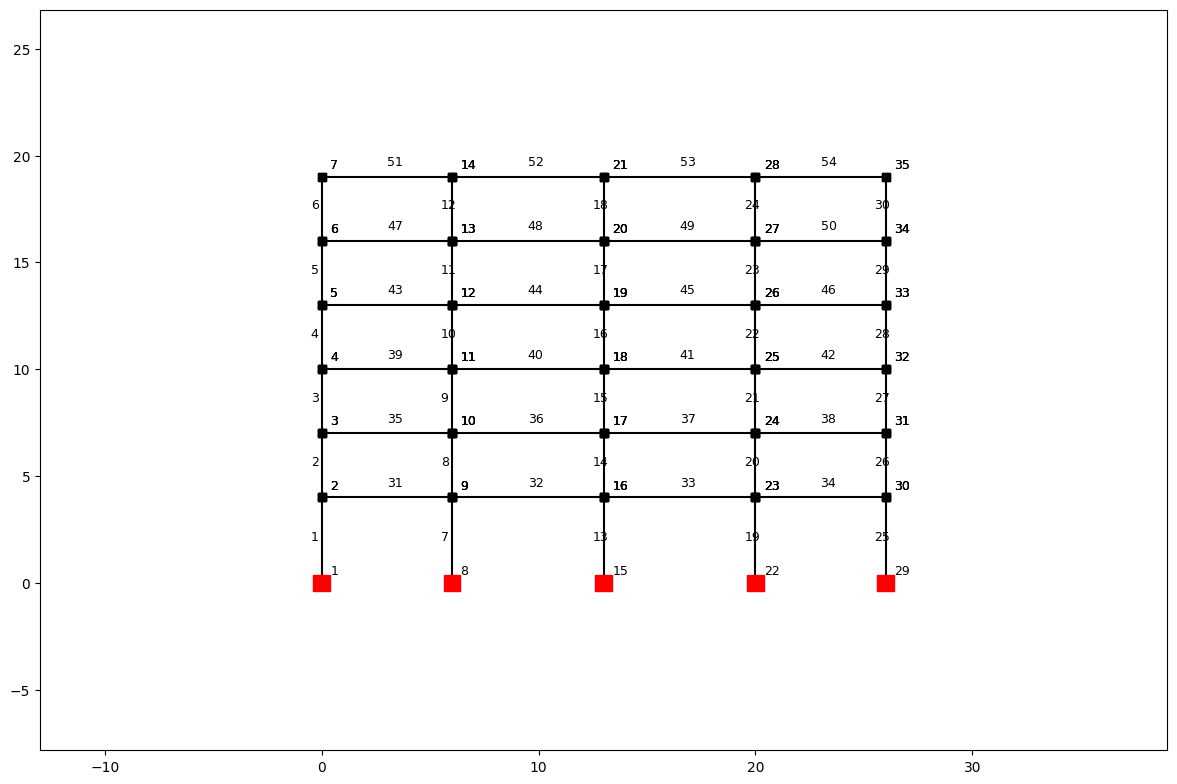

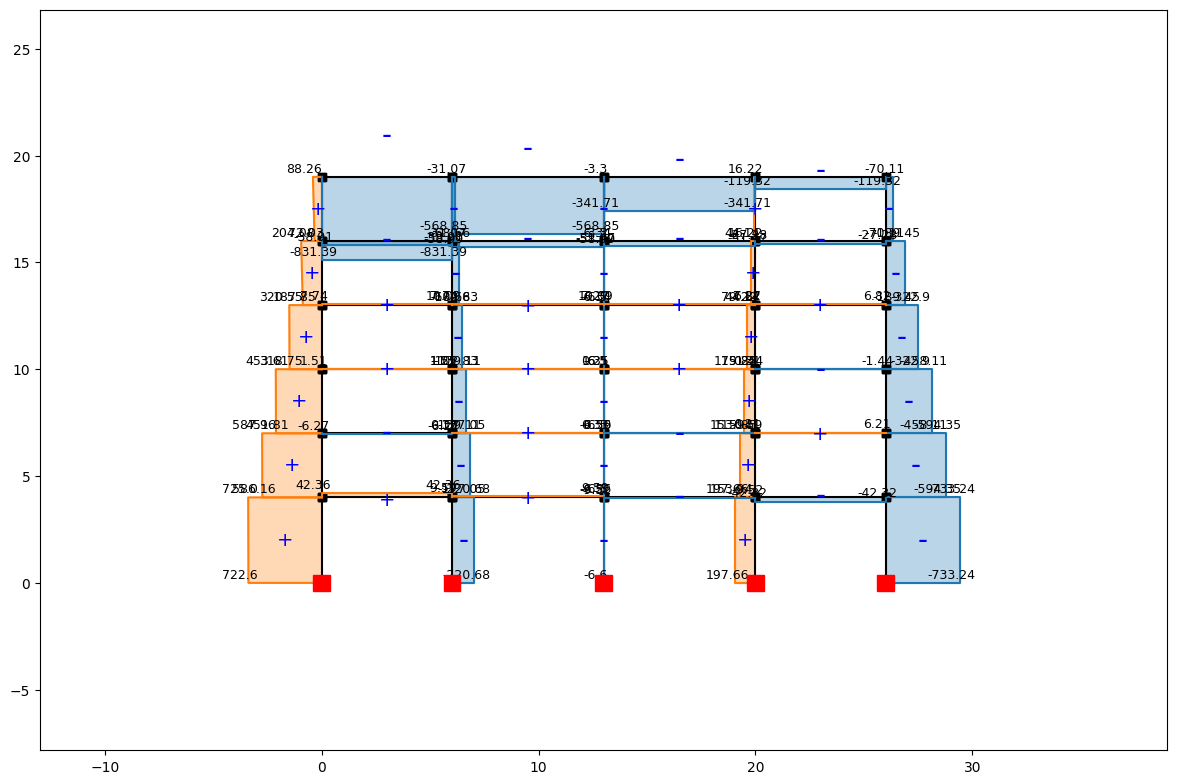

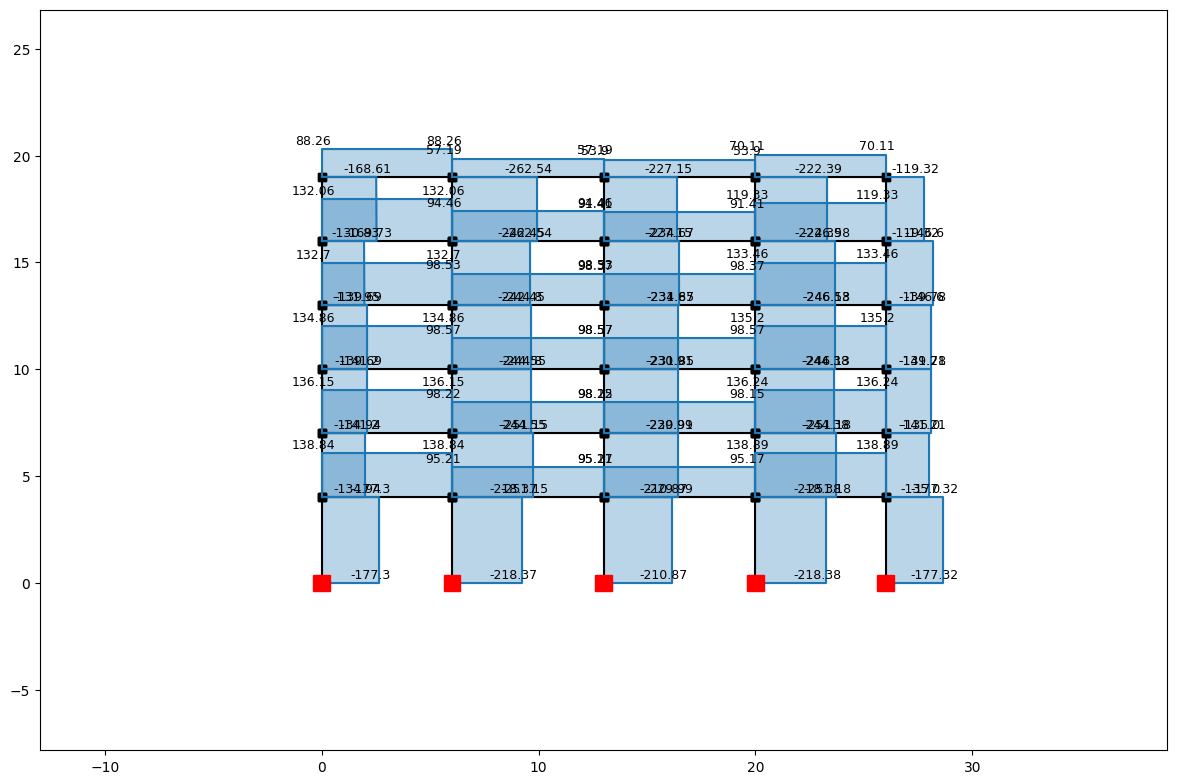

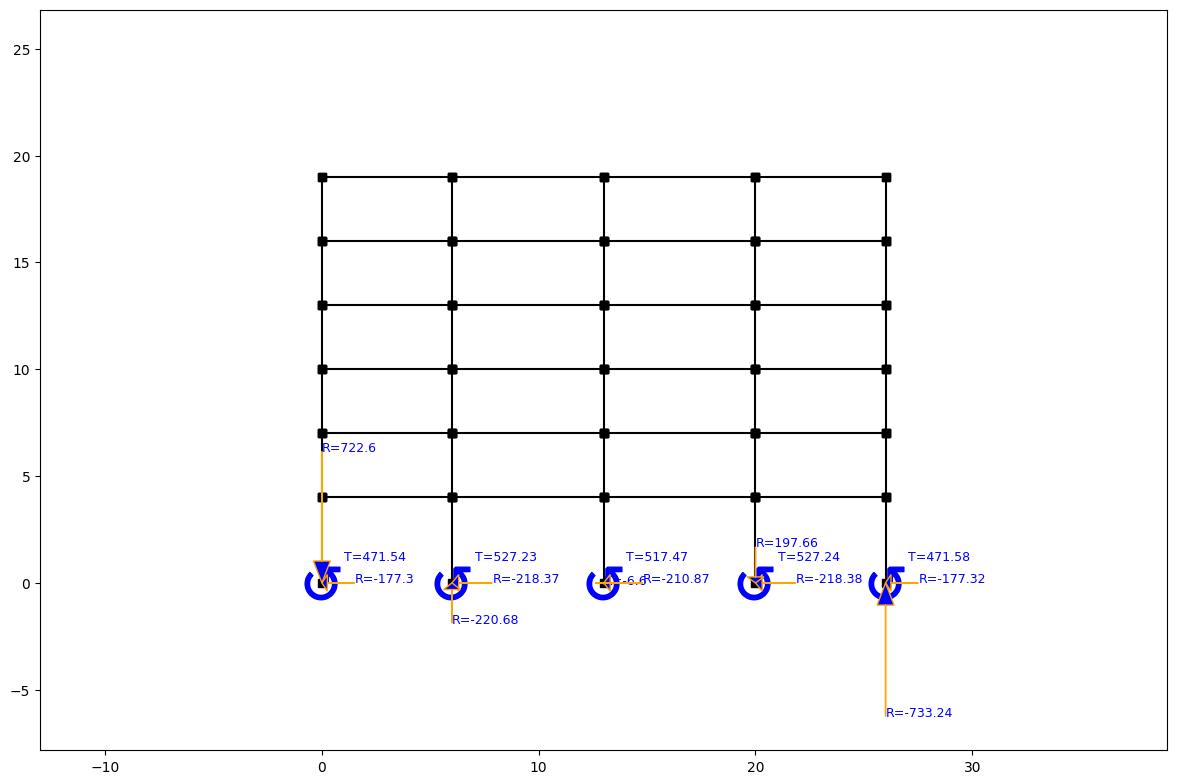

{'id': 1, 'Fx': np.float64(177.29690009204884), 'Fy': np.float64(722.5992737763722), 'Tz': np.float64(-471.5401179366046), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
{'id': 8, 'Fx': np.float64(218.3740689634494), 'Fy': np.float64(-220.6812830885658), 'Tz': np.float64(-527.2289567457912), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
{'id': 15, 'Fx': np.float64(210.87430468749844), 'Fy': np.float64(-6.59500403580866), 'Tz': np.float64(-517.4720569039484), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
{'id': 22, 'Fx': np.float64(218.3823617118612), 'Fy': np.float64(197.66001823027435), 'Tz': np.float64(-527.2417201283163), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
{'id': 29, 'Fx': np.float64(177.32236454514225), 'Fy': np.float64(-733.2430048822732), 'Tz': np.float64(-471.57663495516925), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}


{'id': 5,
 'length': 3.0,
 'alpha': 1.5707963267948966,
 'umax': np.float64(0.0007571535972126001),
 'umin': np.float64(0.00039537206419512763),
 'u': array([0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001, 0.001, 0.001]),
 'wmax': np.float64(-0.002349912527762374),
 'wmin': np.float64(0.001974134422829237),
 'w': array([ 0.   , -0.   , -0.001, -0.001, -0.001, -0.002, -0.002, -0.002,
        -0.002, -0.002, -0.002, -0.002, -0.002, -0.002, -0.002, -0.002,
        -0.002, -0.002, -0.002, -0.001, -0.001, -0.001, -0.001, -0.001,
        -0.   , -0.   ,  0.   ,  0.   ,  0.001,  0.001,  0.001,  0.001,
         0.001,  0.001,  0.002,  0.002,  0.002,  0.002,  0.002,  0.002

In [184]:
res = Comb0.solve(ss)

s1 = res["combination"]
s1.show_structure()
s1.show_axial_force(scale=1)
s1.show_shear_force()
s1.show_reaction_force(scale=1)


for x in ejes_x:
    print(s1.get_node_results_system(s1.find_node_id([x,0])))

s1.get_element_results(element_id=5, verbose=True)
